You are working as a Data Scientist in a fintech company.
The company wants to predict whether a customer will default on a loan.

- You are given a dataset with:
    - Customer demographic data
    - Financial behavior features
    - Transaction history
    
Single models are giving moderate performance, but management wants better accuracy and stability.

1. Load the dataset
2. Identify:
    - Target variable
    - Numerical features
    - Categorical features

3. Handle:
    - Missing values
    - Encoding (if needed)
4. Split data into:
    - Train
    - Test
    
📌 Explain why data preprocessing is important for stacking.

Task 2: Build Base Models
Train at least THREE different base models from the list below:
    Logistic Regression
    Decision Tree
    KNN
    Random Forest
    Support Vector Machine

For each base model:
1. Train the model using training data
2. Evaluate performance using:
Accuracy
3. Display results clearly

📌 Requirement:
Mention which base model performs best and why.

Task 3: Implement Stacking Model (CORE TASK)
1. Use predictions from base models as input features
2. Train a meta-model (Logistic Regression is recommended)
3. Ensure:
    No data leakage
    Proper train–test separation

📌 Requirement:
Explain how stacking improves performance compared to single models.


🔹 Task 4: Evaluation & Comparison
Compare the following models:
    Best individual base model
    Stacking ensemble model

Use:
    Accuracy score
    Confusion Matrix

📌 Requirement:
Is stacking always better than individual models?
Justify your answer based on results.



In [217]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [218]:
df = pd.read_csv('train_Loan_Prediction.csv')

In [219]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [221]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [222]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [223]:
print(df.shape)

(614, 13)


## Outliers

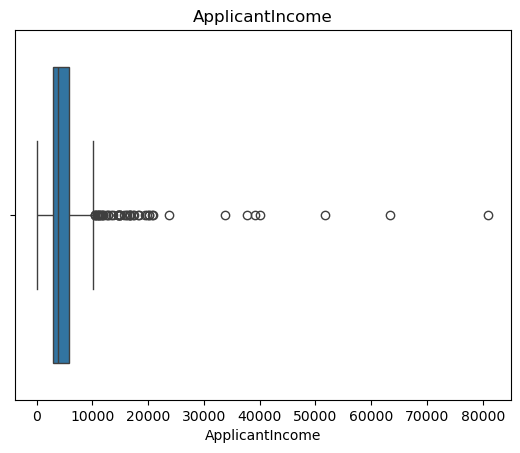

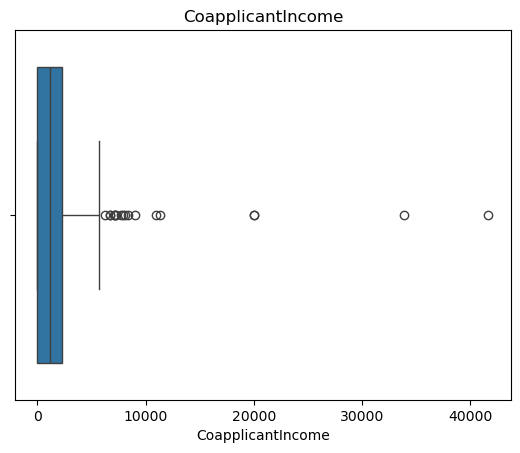

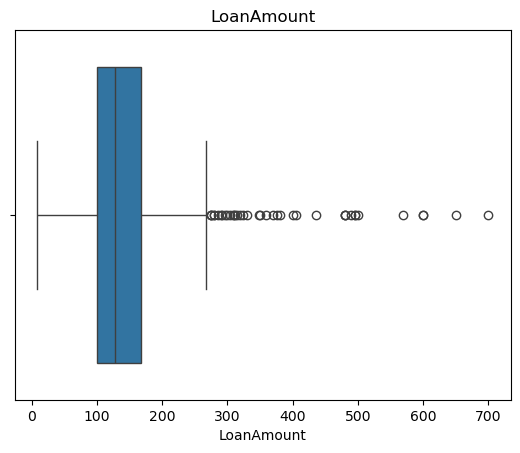

In [224]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [225]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)


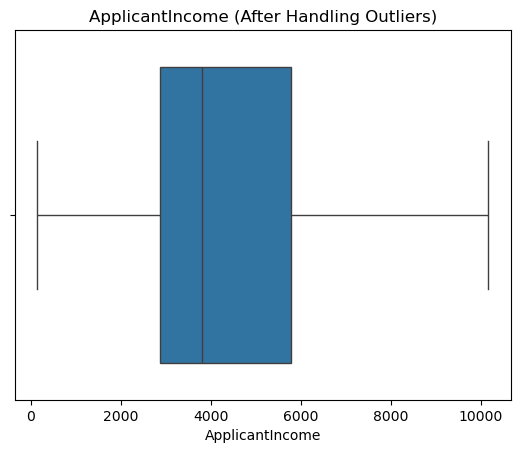

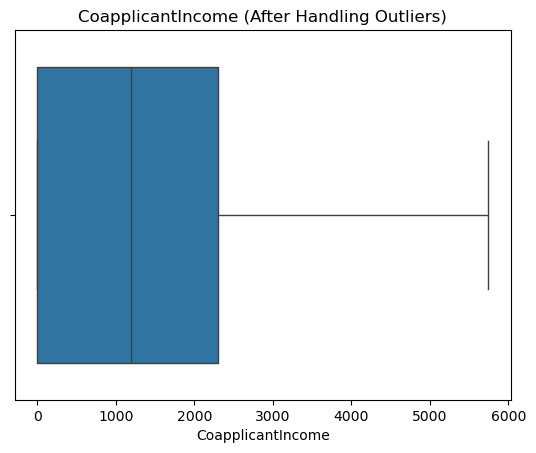

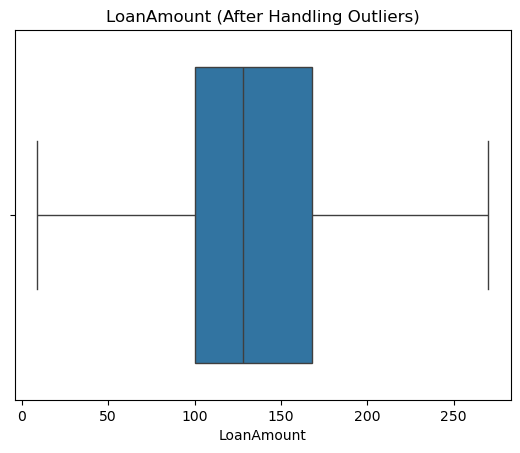

In [226]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col + " (After Handling Outliers)")
    plt.show()


## Handling Missing Values

In [227]:
num_cols_fill = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [228]:
for col in num_cols_fill:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\rakes\AppData\Local\Temp\ipykernel_5040\1402098291.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [229]:
cat_cols_fill = ['Gender', 'Married', 'Dependents', 'Self_Employed']

In [230]:
for col in cat_cols_fill:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\rakes\AppData\Local\Temp\ipykernel_5040\3341529141.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [231]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## Encode categorical columns (Object → Numeric)

In [232]:
df.drop(columns=['Loan_ID'], inplace=True)

In [233]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [234]:
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})

In [235]:
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})

In [236]:
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})

In [237]:
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)


C:\Users\rakes\AppData\Local\Temp\ipykernel_5040\3517865738.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)


In [238]:
# Replace '3+' with 3
df['Dependents'] = df['Dependents'].replace('3+', 3)

# Convert to numeric (NaN stays NaN)
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

# Replace NaN with mode
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

# Now convert to int
df['Dependents'] = df['Dependents'].astype(int)


C:\Users\rakes\AppData\Local\Temp\ipykernel_5040\3395631421.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)


In [239]:
df['Property_Area'] = df['Property_Area'].map({
    'Rural': 0,
    'Semiurban': 1,
    'Urban': 2
})

In [240]:
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    float64
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(5), int64(7)
memory usage: 57.7 KB


In [242]:
# Features (independent variables)
X = df.drop('Loan_Status', axis=1)

# Target (dependent variable)
y = df['Loan_Status']

In [243]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [244]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Define Base Models

In [245]:
base_models = [
    ('lr', LogisticRegression()),
    ('dt', DecisionTreeClassifier(max_depth = 3)),
    ('knn', KNeighborsClassifier(n_neighbors = 5))
]

## Meta Model

Meta Model decodes decides how to combine predictions

In [246]:
meta_model = LogisticRegression()

## Build Stacking Classifier

In [247]:
classifier = StackingClassifier(
    estimators = base_models,
    final_estimator = meta_model,
    cv = 5
)

In [248]:
classifier.fit(X_train, y_train)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [249]:
y_pred = classifier.predict(X_test)

In [250]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7886178861788617
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [251]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[18 25]
 [ 1 79]]


<Axes: >

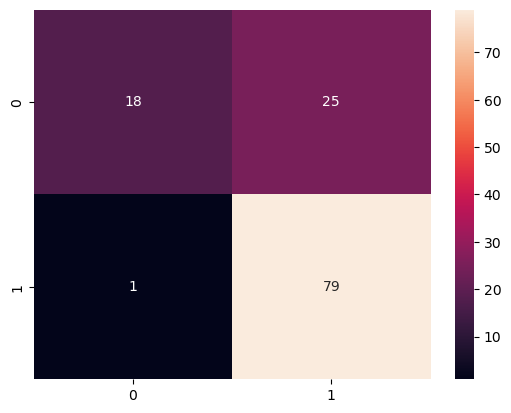

In [252]:

cm = confusion_matrix(y_test , y_pred)
sns.heatmap(cm , annot=True)


1. 1️⃣ App Title & Description
    Title:

    🎯 Smart Loan Approval System – Stacking Model

    Short Description:

        “This system uses a Stacking Ensemble Machine Learning model to predict whether a loan will be approved by combining multiple ML models for better decision making.”


2. 2️⃣ Input Section (Sidebar or Main Panel)
    The user should enter the following applicant details:
    - Applicant Income – Number input
    - Co-Applicant Income – Number input
    - Loan Amount – Number input
    - Loan Amount Term – Number input
    - Credit History – Radio button (Yes / No)
    - Employment Status – Dropdown (Salaried / Self-Employed)
    - Property Area – Dropdown (Urban / Semi-Urban / Rural)

    📌 All inputs must be user-friendly and clearly labeled.


3. 3️⃣ Model Architecture Display (IMPORTANT – For Stacking Understanding)
    Display a read-only section explaining the stacking structure used:

    Base Models Used:
    - Logistic Regression
    - Decision Tree
    - Random Forest

    Meta Model Used:
    - Logistic Regression

    📌 This helps students understand how stacking works internally.

4. 4️⃣ Prediction Button
    Add a button:

    🔘 “Check Loan Eligibility (Stacking Model)”
    On click:
    - Collect user inputs
    - Pass data to base models
    - Use base model predictions as input to meta-model


5. 5️⃣ Output Section (Main Result)
    Display the prediction result clearly:
    - ✅ Loan Approved (Green highlight)
    - ❌ Loan Rejected (Red highlight)

    - Display:
        📊 Base Model Predictions
        - Logistic Regression → Approved / Rejected
        - Decision Tree → Approved / Rejected
        - Random Forest → Approved / Rejected
    - 🧠 Final Stacking Decision
    - 📈 Confidence Score (%) (if implemented)


6. 6️⃣ Business Explanation (VERY IMPORTANT ⭐)
    Display a short explanation in simple business language:

        “Based on income, credit history, and combined predictions from multiple models, the applicant is likely / unlikely to repay the loan.
        Therefore, the stacking model predicts loan approval / rejection.”

    📌 This section is mandatory — marks will be deducted if missing.


7. 7️⃣ UI Quality Guidelines (Mandatory)
    - Use sidebar for inputs (preferred)
    - Clean layout
    - Clear headings
    - Proper spacing
    - Color-coded results (Green / Red)
